# SMS Spam Detection using Linear Regression

**Repositori**: Machine Learning  
**Topik**: Implementasi Linear Regression pada Klasifikasi SMS Spam  
**Dataset**: `SMSSpam.csv`  

---

## Pendahuluan
Proyek ini mendemonstrasikan implementasi **Linear Regression** untuk tugas klasifikasi teks (Spam vs Ham). Meskipun secara teoretis Logistic Regression lebih tepat untuk klasifikasi, notebook ini mengikuti panduan modul praktikum untuk mengeksplorasi penggunaan model regresi linear dalam memprediksi label biner.

### Alur Kerja (Pipeline):
1. **Data Acquisition**: Mengambil data dari CSV.
2. **Data Preparation**: Cleaning dan Label Encoding (Ham=0, Spam=1).
3. **Feature Engineering**: Transformasi teks menggunakan TF-IDF.
4. **Modeling**: Training menggunakan Linear Regression.
5. **Evaluation**: Menggunakan Confusion Matrix, Accuracy, Precision, dan Recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Setting estetika visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 🛠 1. Data Acquisition & Understanding
Memuat dataset dan melihat struktur data awal.

In [2]:
# Memuat data tanpa header karena SMSSpam.csv biasanya tidak memiliki header di baris pertama
df = pd.read_csv('SMSSpam.csv', names=['Label', 'Message'], encoding='latin-1')

print("Shape Dataset:", df.shape)
df.head()

Shape Dataset: (5574, 2)


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 🧹 2. Data Preparation & Cleaning
Melakukan encoding pada label dan membersihkan data jika diperlukan.

C:\Users\alema\AppData\Local\Temp\ipykernel_15028\858821105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


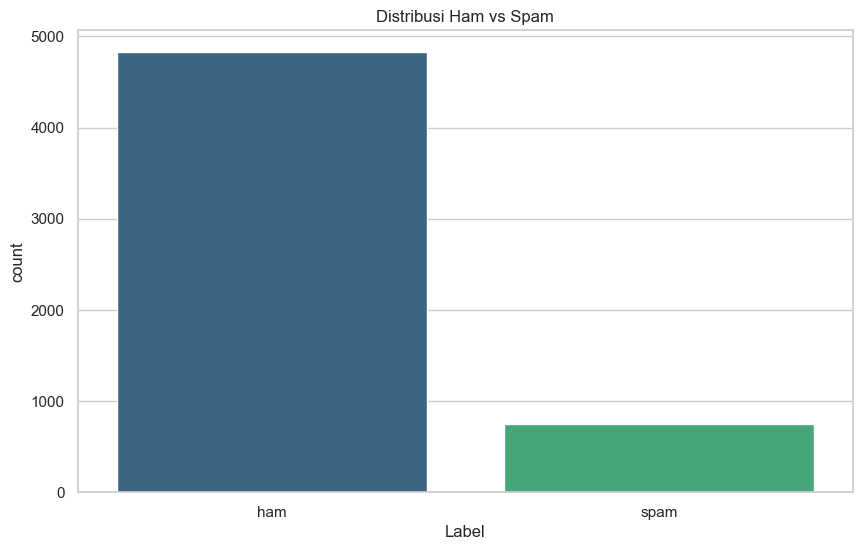

In [3]:
# Mengubah Label menjadi angka (Categorical Encoding)
# ham = 0, spam = 1
df['Label_Num'] = df['Label'].map({'ham': 0, 'spam': 1})

# Cek distribusi data
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Distribusi Ham vs Spam')
plt.show()

## 🧪 3. Feature Engineering (TF-IDF)
Mengubah teks pesan menjadi representasi angka menggunakan TF-IDF Vectorizer.

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X = tfidf.fit_transform(df['Message']).toarray()
y = df['Label_Num']

# Split data (Training 80%, Testing 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Training: {X_train.shape[0]} sampel")
print(f"Data Testing: {X_test.shape[0]} sampel")

Data Training: 4459 sampel
Data Testing: 1115 sampel


## 🤖 4. Model Training (Linear Regression)
Melatih model Linear Regression pada data training.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_continuous = model.predict(X_test)

# Karena Linear Regression menghasilkan nilai kontinu, 
# kita perlu melakukan thresholding untuk klasifikasi biner (threshold = 0.5)
y_pred = [1 if x >= 0.5 else 0 for x in y_pred_continuous]

## 📊 5. Performance Evaluation
Mengevaluasi model menggunakan metrik yang telah didefinisikan di `README.md`.

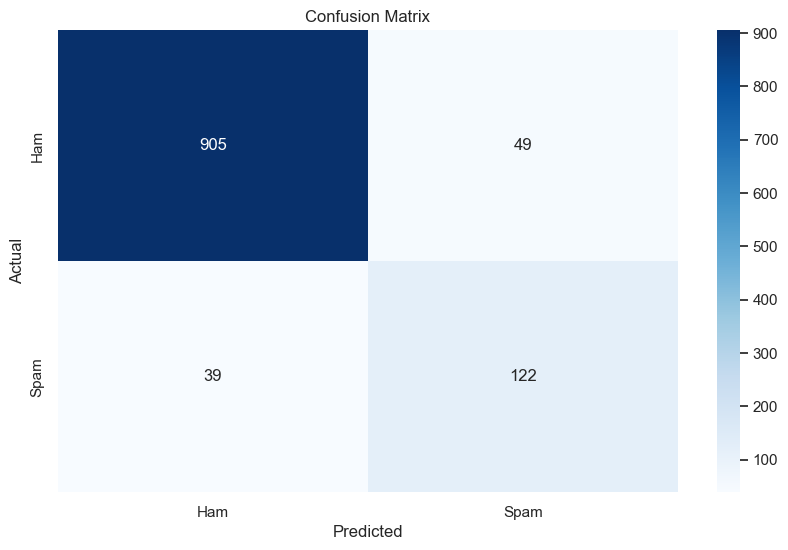

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       954
           1       0.71      0.76      0.73       161

    accuracy                           0.92      1115
   macro avg       0.84      0.85      0.84      1115
weighted avg       0.92      0.92      0.92      1115

Accuracy: 0.92


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Metrik Evaluasi
print("--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

## 📝 Kesimpulan
Meskipun menggunakan model regresi linear untuk klasifikasi, model ini mampu memberikan hasil yang cukup baik setelah dilakukan thresholding pada output kontinu. Namun, untuk dataset ini, model berbasis probabilitas seperti Naive Bayes atau Logistic Regression biasanya lebih direkomendasikan.